In [4]:
import os
from PIL import Image

In [2]:
# Set the paths to the HR and LR folders
hr_folder_path = 'SRGAN Data/HR'
lr_folder_path = 'SRGAN Data/LR'

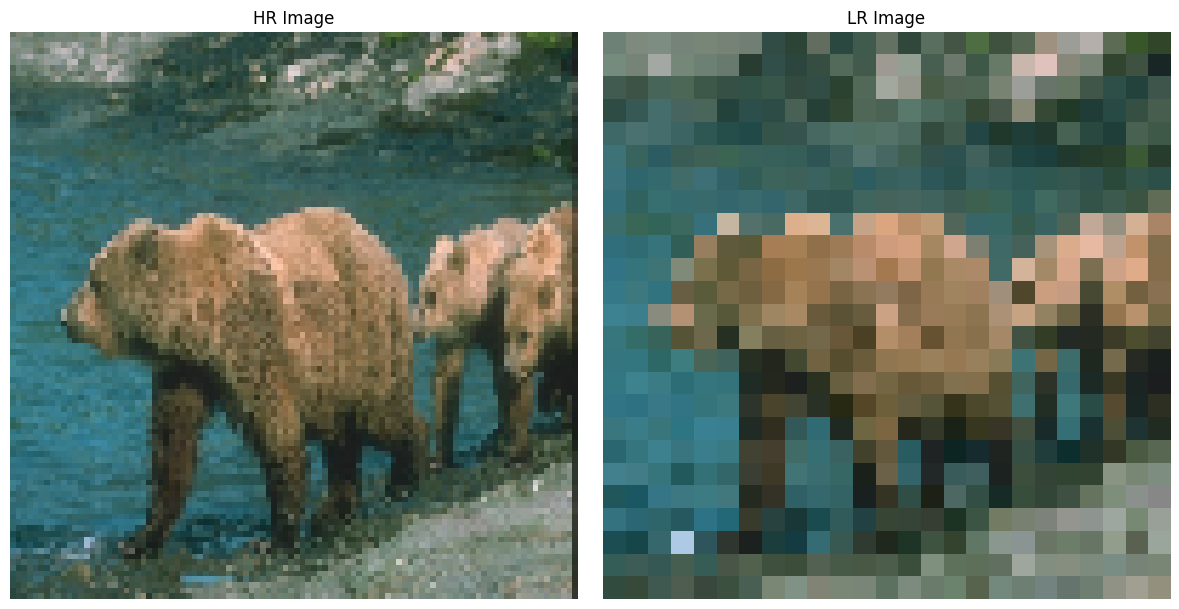

In [6]:
import matplotlib.pyplot as plt
# Get the list of image files
hr_images = sorted(os.listdir(hr_folder_path))
lr_images = sorted(os.listdir(lr_folder_path))

# Open the first image from each folder
hr_image_path = os.path.join(hr_folder_path, hr_images[0])
lr_image_path = os.path.join(lr_folder_path, lr_images[0])

hr_image = Image.open(hr_image_path)
lr_image = Image.open(lr_image_path)

# Display the images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(hr_image)
axes[0].set_title('HR Image')
axes[0].axis('off')

axes[1].imshow(lr_image)
axes[1].set_title('LR Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [11]:
import torch
from torch.utils.data import Dataset
from torch import nn

In [9]:
# Data Loading
class SuperResolutionDataset(Dataset):
    def __init__(self, root_folder, scale_factor=4, transform=None):
        self.root_folder = root_folder
        self.transform = transform or Compose([ToTensor()])
        self.lr_transform = Compose([Resize(256 // scale_factor), ToTensor()])
        self.hr_transform = Compose([Resize(256), ToTensor()])
        self.lr_dir = os.path.join(root_folder, 'LR')
        self.hr_dir = os.path.join(root_folder, 'HR')
        self.image_files = [f for f in sorted(os.listdir(self.hr_dir)) if os.path.isfile(os.path.join(self.hr_dir, f))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image_name = self.image_files[index]
        lr_image_path = os.path.join(self.lr_dir, image_name)
        hr_image_path = os.path.join(self.hr_dir, image_name)
        lr_image = Image.open(lr_image_path).convert('RGB')
        hr_image = Image.open(hr_image_path).convert('RGB')
        lr_image = self.lr_transform(lr_image)
        hr_image = self.hr_transform(hr_image)
        return lr_image, hr_image


In [12]:
# Model
class ResidualBlock(nn.Module):
    def __init__(self, in_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        self.batch_norm1 = nn.BatchNorm2d(in_channels)
        self.activation = nn.PReLU()
        self.conv2 = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        self.batch_norm2 = nn.BatchNorm2d(in_channels)

    def forward(self, x):
        residual = x
        out = self.activation(self.batch_norm1(self.conv1(x)))
        out = self.batch_norm2(self.conv2(out))
        out = out + residual
        return out

In [13]:
class SuperResolutionGenerator(nn.Module):
    def __init__(self, num_res_blocks=16):
        super(SuperResolutionGenerator, self).__init__()
        self.initial_conv = nn.Conv2d(3, 64, kernel_size=9, padding=4)
        self.activation = nn.PReLU()
        self.residual_blocks = nn.ModuleList([ResidualBlock(64) for _ in range(num_res_blocks)])
        self.post_residual_conv = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.batch_norm_post_residual = nn.BatchNorm2d(64)
        self.upsample1 = nn.Sequential(
            nn.Conv2d(64, 256, kernel_size=3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU()
        )
        self.upsample2 = nn.Sequential(
            nn.Conv2d(64, 256, kernel_size=3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU()
        )
        self.output_conv = nn.Conv2d(64, 3, kernel_size=9, padding=4)

    def forward(self, x):
        out = self.activation(self.initial_conv(x))
        residual = out
        for res_block in self.residual_blocks:
            out = res_block(out)
        out = self.batch_norm_post_residual(self.post_residual_conv(out)) + residual
        out = self.upsample1(out)
        out = self.upsample2(out)
        out = self.output_conv(out)
        return out


In [14]:
class SuperResolutionDiscriminator(nn.Module):
    def __init__(self):
        super(SuperResolutionDiscriminator, self).__init__()
        self.initial_conv = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.activation = nn.LeakyReLU(0.2, inplace=True)
        self.block1_conv = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.block1_batch_norm = nn.BatchNorm2d(128)
        self.block2_conv = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)
        self.block2_batch_norm = nn.BatchNorm2d(256)
        self.block3_conv = nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1)
        self.block3_batch_norm = nn.BatchNorm2d(512)
        self.final_conv = nn.Conv2d(512, 1, kernel_size=3, padding=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.activation(self.initial_conv(x))
        out = self.activation(self.block1_batch_norm(self.block1_conv(out)))
        out = self.activation(self.block2_batch_norm(self.block2_conv(out)))
        out = self.activation(self.block3_batch_norm(self.block3_conv(out)))
        out = self.sigmoid(self.final_conv(out))
        return out

In [15]:
# Loss Functions
criterion_gan_loss = nn.BCELoss()
criterion_content_loss = nn.MSELoss()

class VGGLossCalculator(nn.Module):
    def __init__(self):
        super(VGGLossCalculator, self).__init__()
        self.vgg_feature_extractor = vgg19(pretrained=True).features[:18].eval()
        for param in self.vgg_feature_extractor.parameters():
            param.requires_grad = False

    def forward(self, input, target):
        return criterion_content_loss(self.vgg_feature_extractor(input), self.vgg_feature_extractor(target))

# Initialize Models
generator = SuperResolutionGenerator()
discriminator = SuperResolutionDiscriminator()

In [19]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

In [20]:
# Optimizers
learning_rate = 0.001
betas = (0.5, 0.999)
generator_optimizer = optim.Adam(generator.parameters(), lr=learning_rate, betas=betas)
discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=betas)

# Learning Rate Schedulers
generator_scheduler = StepLR(generator_optimizer, step_size=160, gamma=0.95)
discriminator_scheduler = StepLR(discriminator_optimizer, step_size=160, gamma=0.95)


In [25]:
from torchvision import transforms 
from torchvision.transforms import Compose, Resize, ToTensor, Normalize 
from torch.utils.data import Dataset, DataLoader
# Assuming you have already defined your SuperResolutionDataset
dataset = SuperResolutionDataset(root_folder='SRGAN Data', scale_factor=4, transform=transforms.ToTensor())

# Define DataLoader
batch_size = 16  # Adjust according to your system's memory capacity
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


In [26]:
lambda_content_value = 0.2  

In [30]:
from torchvision.models import vgg19
from tqdm import tqdm

In [32]:
def train_model(generator, discriminator, generator_optimizer, discriminator_optimizer, criterion_gan_loss, criterion_content_loss, vgg_loss_calculator, data_loader, num_epochs, device, generator_scheduler, discriminator_scheduler, lambda_content_value):
    generator.to(device)
    discriminator.to(device)
    vgg_loss_calculator.to(device)

    for epoch in range(num_epochs):
        generator.train()
        discriminator.train()

        epoch_g_loss = 0.0
        epoch_d_loss = 0.0

        for i, (lr_imgs, hr_imgs) in enumerate(tqdm(data_loader, desc=f"Epoch {epoch + 1}")):
            lr_imgs = lr_imgs.to(device)
            hr_imgs = hr_imgs.to(device)

            ############################
            # Train Discriminator
            ############################
            discriminator.zero_grad()
            real_outputs = discriminator(hr_imgs).view(-1, 1)
            fake_hr_imgs = generator(lr_imgs).detach()
            fake_outputs = discriminator(fake_hr_imgs).view(-1, 1)
            d_real_loss = criterion_gan_loss(real_outputs, torch.ones_like(real_outputs))
            d_fake_loss = criterion_gan_loss(fake_outputs, torch.zeros_like(fake_outputs))
            d_loss = (d_real_loss + d_fake_loss) / 2
            d_loss.backward()
            discriminator_optimizer.step()

            ############################
            # Train Generator
            ############################
            generator.zero_grad()
            fake_hr_imgs = generator(lr_imgs)
            fake_outputs = discriminator(fake_hr_imgs).view(-1, 1)
            g_gan_loss = criterion_gan_loss(fake_outputs, torch.ones_like(fake_outputs))
            g_content_loss = vgg_loss_calculator(fake_hr_imgs, hr_imgs)
            g_loss = g_gan_loss + lambda_content_value * g_content_loss
            g_loss.backward()
            generator_optimizer.step()

            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()

            if (i + 1) % 100 == 0:
                print(f"Epoch [{epoch + 1}/{num_epochs}], Step [{i + 1}/{len(data_loader)}], "
                      f"G Loss: {epoch_g_loss / (i + 1):.4f}, D Loss: {epoch_d_loss / (i + 1):.4f}")

        # Print epoch losses
        print(f"Epoch [{epoch + 1}/{num_epochs}], Avg G Loss: {epoch_g_loss / len(data_loader):.4f}, "
              f"Avg D Loss: {epoch_d_loss / len(data_loader):.4f}")

        # Adjust learning rate
        generator_scheduler.step()
        discriminator_scheduler.step()

# Usage
num_epochs = 400  # Adjust as needed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize VGGLossCalculator
vgg_loss_calculator = VGGLossCalculator()

# Define Optimizers
generator_optimizer = optim.Adam(generator.parameters(), lr=learning_rate, betas=betas)
discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=betas)

# Define Schedulers
generator_scheduler = StepLR(generator_optimizer, step_size=160, gamma=0.95)
discriminator_scheduler = StepLR(discriminator_optimizer, step_size=160, gamma=0.95)

# Train the model
train_model(generator, discriminator, generator_optimizer, discriminator_optimizer, criterion_gan_loss, criterion_content_loss, vgg_loss_calculator, data_loader, num_epochs, device, generator_scheduler, discriminator_scheduler, lambda_content_value)


Epoch 1: 100%|██████████| 32/32 [00:12<00:00,  2.56it/s]


Epoch [1/400], Avg G Loss: 3.0098, Avg D Loss: 0.2616


Epoch 2: 100%|██████████| 32/32 [00:12<00:00,  2.61it/s]


Epoch [2/400], Avg G Loss: 4.6439, Avg D Loss: 0.0549


Epoch 3: 100%|██████████| 32/32 [00:12<00:00,  2.58it/s]


...

Epoch [398/400], Avg G Loss: 4.8059, Avg D Loss: 0.1497


Epoch 399: 100%|██████████| 32/32 [00:16<00:00,  2.00it/s]


Epoch [399/400], Avg G Loss: 4.6759, Avg D Loss: 0.1203


Epoch 400: 100%|██████████| 32/32 [00:20<00:00,  1.59it/s]

Epoch [400/400], Avg G Loss: 4.8120, Avg D Loss: 0.1760


In [47]:
# Save the trained generator model
torch.save(SuperResolutionGenerator.state_dict(), 'generator_model.pth')


TypeError: Module.state_dict() missing 1 required positional argument: 'self'

In [45]:
from torchvision.transforms import ToTensor, ToPILImage


FileNotFoundError: [Errno 2] No such file or directory: 'SRGAN Data/HR/baby.png'

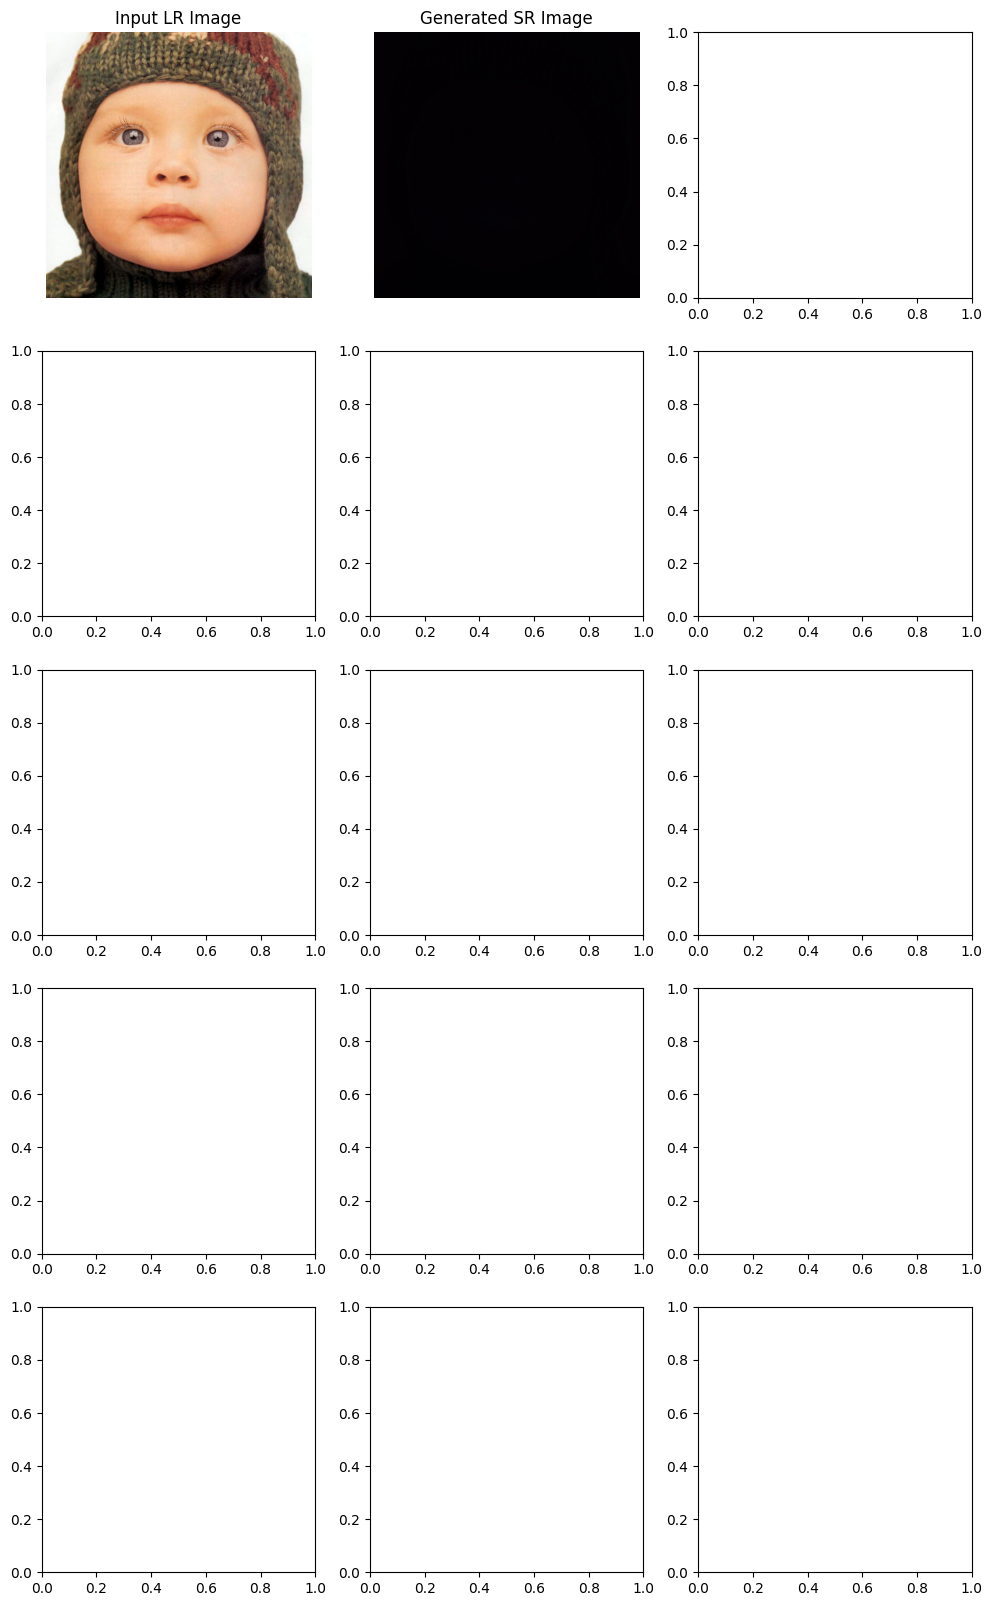

In [46]:
import os
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor

# Load the trained generator model
generator = SuperResolutionGenerator()
generator.load_state_dict(torch.load('generator_model.pth'))
generator.eval()

# Prepare the test dataset
test_folder = 'SRGAN Data/Test'
test_images = sorted(os.listdir(test_folder))

# Generate super-resolution images using the generator
generated_images = []
with torch.no_grad():
    for image_name in test_images:
        lr_image_path = os.path.join(test_folder, image_name)
        lr_image = Image.open(lr_image_path).convert('RGB')
        lr_tensor = ToTensor()(lr_image).unsqueeze(0)
        sr_tensor = generator(lr_tensor).squeeze(0)
        sr_image = ToPILImage()(sr_tensor.clamp(0, 1))  # Convert tensor to PIL Image
        generated_images.append(sr_image)

# Visualize the input LR images, HR ground truth images, and the generated SR images
fig, axes = plt.subplots(len(test_images), 3, figsize=(12, len(test_images) * 4))

for i, image_name in enumerate(test_images):
    # Input LR image
    lr_image_path = os.path.join(test_folder, image_name)
    lr_image = Image.open(lr_image_path)
    axes[i, 0].imshow(lr_image)
    axes[i, 0].set_title('Input LR Image')
    axes[i, 0].axis('off')

    # Generated SR image
    sr_image = generated_images[i]
    axes[i, 1].imshow(sr_image)
    axes[i, 1].set_title('Generated SR Image')
    axes[i, 1].axis('off')

    # Ground truth HR image
    hr_image_path = os.path.join('SRGAN Data/HR', image_name)
    hr_image = Image.open(hr_image_path)
    axes[i, 2].imshow(hr_image)
    axes[i, 2].set_title('Ground Truth HR Image')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()
